# Kapitel 3 - Regression

## Faktafrågor

### 1. Vad kännetecknar regressionsproblem? Ge några exempel på tillämpningsområden.

Regressionsproblem kännetecknas av att utdatan (y) är kontinuerlig, alltså den kan anta typ vilket värde som helst inom ett intervall, inte bara några få bestämda kategorier. Några exempel på tillämpningsområden är att predicera huspriser, temperatur eller löner baserat på olika variabler (x).

### 2. Förklara utvärderingsmåtten RMSE, MSE och MAE.

Alla tre mäter hur mycket modellen gissar fel, alltså skillnaden mellan de sanna värdena och det som modellen predikterat. MAE (Mean Absolute Error) tar bara det genomsnittliga felet rakt av utan att göra nåt konstigt med det. MSE (Mean Squared Error) kvadrerar felen innan man tar medelvärdet, så stora fel blir straffade extra hårt. RMSE (Root Mean Squared Error) tar sen roten ur MSE så felet hamnar i samma enhet igen och blir lättare att förstå.

### 3. Om vi ska rangordna olika modeller, spelar det någon roll om RMSE eller MSE används? Varför?

Nej det spelar inte nån stor roll, blir samma rangordning ändå. RMSE är bara roten ur MSE så talen blir mindre och lättare att greppa, men vilken modell som är bäst ändras inte.

### 4. Förklara mycket översiktligt vad gradient descent är.

Gradient descent är en metod där modellen provar sig fram steg för steg och justerar sig tills felet blir så litet som möjligt.

### 5. Vad är the bias variance trade-off? Varför är mer komplexa modeller inte alltid bättre?

En för komplex modell fångar nästan träningsdatan perfekt men klarar inte ny data lika bra. En för enkel modell missar mönstret helt istället. Man vill ha nåt mitt emellan så modellen funkar bra även på ny data.

### 6. Förklara översiktligt hur respektive modell fungerar: a) Linjär regression, b) Ridge, c) Lasso, d) Elastic net, e) SVM, f) Beslutsträd, g) Ensemble learning, h) Random forest

a) Linjär regression - drar en rak linje genom punkterna, enkelt och snabbt, fungerar bäst när sambandet är typ rakt.

b) Ridge regression - liknar linjär regression men lägger till en straff-term som gör att modellen håller sig till mindre koefficienter så den inte överanpassas lika lätt.

c) Lasso regression - liknar ridge men kan dra ner oviktiga variabler helt till noll, så den väljer automatiskt ut dom viktigaste egenskaperna och slänger resten.

d) Elastic net - nåt mittemellan ridge och lasso, kombinerar bägge straff-termerna.

e) SVM (support vector machines) - ritar en gränslinje med så bred marginal som möjligt till närmaste datapunkterna.

f) Beslutsträd - delar upp datan med ja/nej-frågor tills den kommer fram till ett svar, kan lätt bli överanpassat.

g) Ensemble learning - flera modeller slås ihop och samarbetar, genom röstning eller medelvärde, vilket ger säkrare gissningar jämfört med bara en modell.

h) Random forest - en mängd olika beslutsträd som tränas på slumpmässig data och röstar ihop ett slutsvar, minskar risken för överanpassning som vanliga beslutsträd har.

### 7. Vad menas med white box modeller och black box modeller?

White box modeller är modeller som är lätta att förstå, man kan se tydligt vilka variabler som används och hur dom räknas ihop till ett resultat, t.ex. linjär regression eller ett enkelt beslutsträd. Black box modeller är svårare att förstå, beräkningarna kan inte ses tydligt på alla ställen, t.ex. neurala nätverk eller random forest.

### 8. Vad är skillnaden mellan bagging och pasting?

Bagging och pasting är två sätt att träna delmodellerna i en ensemble på olika delar av datan. Bagging plockar ut datapunkter med återläggning, alltså samma datapunkt kan hamna i flera olika delmodeller. Pasting plockar ut datapunkter utan återläggning, så varje datapunkt kan bara användas en gång i en delmodell.

## Resonemangfrågor

### 9. Förklara hur man kan tolka figur 3.1 på sidan 113.

Vi ser en linjär regression. De svarta prickarna är sanna värden (y_i) för varje x (ålder). Blå linjen är regressionslinjen med predikterade värden. De röda linjerna är avståndet mellan sanna värdet och det predikterade värdet, alltså avvikelsen (residualen).

### 10. Förklara hur man kan tolka figur 3.13 på sidan 140. Hur hänger den ihop med figur 3.14 på sidan 141?

Figur 3.13 är ett beslutsträd, den ställer ja/nej-frågor (typ är X2 mindre än 0.438) och sorterar datan ner till fyra olika rutor beroende på svaren. Figur 3.14 visar samma sak fast som en bild, dom fyra färgade rutorna är dom fyra rutorna från trädet. Punkter i samma ruta får samma predikterade värde.

### 11. Vad är determinationskoefficienten (R²)?

R² visar hur bra modellen förklarar datan, mellan 0 och 1. 1 betyder perfekt, 0 betyder att modellen inte förklarar nåt alls.

## Koduppgifter

### 13. EDA på datasetet "hr_employee_data.xlsx" (ingen ML-modellering ännu).

#### Ladda in datan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("data/hr_employee_data.xlsx")
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


#### Grundläggande info om datan

In [2]:
print(df.shape)
df.info()

(14999, 11)
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


In [3]:
df.isnull().sum()  # kolla om det finns saknade värden

Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [4]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


#### Målvariabeln: left (personalomsättning)

In [5]:
df["left"].value_counts(normalize=True) * 100  # andel i procent som slutat vs stannat

left
0    76.191746
1    23.808254
Name: proportion, dtype: float64

#### Satisfaction_level vs left

In [6]:
df.groupby("left")["satisfaction_level"].mean()  # medel-trivsel för dom som stannat (0) vs slutat (1)

left
0    0.666810
1    0.440098
Name: satisfaction_level, dtype: float64

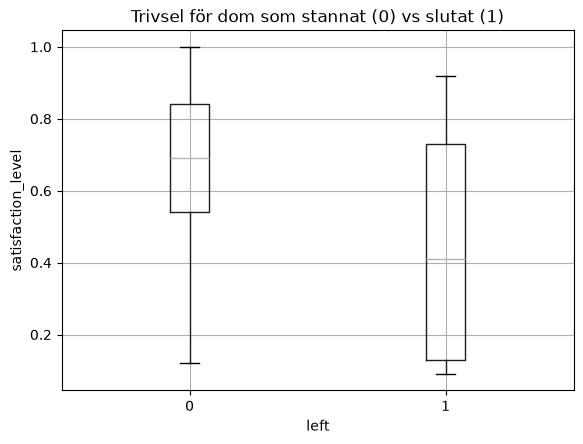

In [7]:
df.boxplot(column="satisfaction_level", by="left")
plt.xlabel("left")
plt.ylabel("satisfaction_level")
plt.title("Trivsel för dom som stannat (0) vs slutat (1)")
plt.suptitle("")
plt.show()

#### Salary och Department vs left

In [8]:
df.groupby("salary")["left"].mean() * 100  # andel i procent som slutat per lönenivå

salary
high       6.628941
low       29.688354
medium    20.431275
Name: left, dtype: float64

In [9]:
df.groupby("Department")["left"].mean().sort_values(ascending=False) * 100  # andel i procent som slutat per avdelning

Department
hr             29.093369
accounting     26.597132
technical      25.625000
support        24.899058
sales          24.492754
marketing      23.659674
IT             22.249389
product_mng    21.951220
RandD          15.374841
management     14.444444
Name: left, dtype: float64

#### Slutsats för ledningsgruppen

Av alla anställda har ca 24% slutat (left=1). Dom som slutat har klart lägre trivsel i snitt (0.44) jämfört med dom som stannat (0.67). Personalomsättningen är också klart högre bland dom med låg lön (ca 30%) jämfört med hög lön (ca 7%). På avdelningsnivå sticker HR, accounting och technical ut med högst andel som slutat, medan management och RandD har lägst. En rekommendation till ledningen hade varit att kolla extra på trivsel och lön i HR/accounting/technical, eftersom det verkar vara dom områdena med störst risk att tappa folk.

### 16. Komplett ML-flöde: modellera diamantpriser från "diamonds.csv".

In [10]:
# TODO